# Data Science Research Capstone

## Predictive Analytics for Marketing Sales Performance

**Author:** Pratiksha  
**Project Type:** Data Science Research Capstone  
**Internship Project:** Final Capstone Project

---

## Abstract

This research project investigates the use of data science and predictive
analytics to understand and predict sales performance across different
marketing methods and regions. The study combines exploratory data analysis,
statistical analysis, feature engineering, and machine learning techniques
to identify patterns that influence sales outcomes.

The project evaluates predictive models using standard regression metrics
including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and
R-squared (R²). The findings are used to derive practical business
implications for marketing strategy and sales planning.

The overall objective is to demonstrate a complete data science workflow
from data preparation and exploratory analysis through predictive modeling,
evaluation, interpretation, and research communication.

# 1. Research Question

## Main Research Question

Can marketing method and regional characteristics be used to predict sales
performance accurately using statistical analysis and machine learning?

## Research Objectives

1. Examine the relationship between marketing methods and sales.
2. Investigate differences in sales across regions.
3. Identify important variables associated with sales performance.
4. Develop predictive machine learning models for sales.
5. Compare model performance using appropriate evaluation metrics.
6. Translate the findings into practical business implications.

## Hypothesis

**H₀:** Marketing method and regional characteristics do not provide useful
information for predicting sales performance.

**H₁:** Marketing method and/or regional characteristics provide useful
information for predicting sales performance.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving marketing_sales.csv.csv to marketing_sales.csv.csv


In [ ]:
import os

print(os.listdir())

['.config', 'daily-demand-series.csv', 'marketing_sales.csv.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("marketing_sales.csv.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (30, 4)


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0



Column names:
['date', 'demand', 'marketing_event', 'holiday']


In [ ]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
display(df.describe(include="all"))

Missing values:


,0
date,0
demand,0
marketing_event,0
holiday,0



Duplicate rows: 0

Data types:
date               object
demand              int64
marketing_event     int64
holiday             int64
dtype: object

Descriptive statistics:


,date,demand,marketing_event,holiday
count,30,30.000000,30.000000,30.000000
unique,30,NaN,NaN,NaN
top,2026-06-01,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,142.100000,0.266667,0.133333
std,NaN,13.839848,0.449776,0.345746
min,NaN,118.000000,0.000000,0.000000
25%,NaN,132.500000,0.000000,0.000000
50%,NaN,142.000000,0.000000,0.000000
75%,NaN,150.250000,0.750000,0.000000


In [ ]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort data chronologically
df = df.sort_values("date").reset_index(drop=True)

# Create time-based features
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_month"] = (df["day"] - 1) // 7 + 1

# Display the prepared dataset
display(df.head(10))

print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

,date,demand,marketing_event,holiday,day,day_of_week,week_of_month
0,2026-06-01,118,0,0,1,0,1
1,2026-06-02,121,0,0,2,1,1
2,2026-06-03,125,0,0,3,2,1
3,2026-06-04,123,0,0,4,3,1
4,2026-06-05,137,1,0,5,4,1
5,2026-06-06,151,1,0,6,5,1
6,2026-06-07,143,0,1,7,6,1
7,2026-06-08,126,0,0,8,0,2
8,2026-06-09,129,0,0,9,1,2
9,2026-06-10,132,0,0,10,2,2


Dataset shape: (30, 7)

Date range:
2026-06-01 00:00:00 to 2026-06-30 00:00:00


# 2. Research Question and Study Design

## Research Question

Can historical demand patterns, marketing events, holidays, and calendar-based
features be used to predict daily demand accurately?

## Study Objectives

1. Analyze daily demand patterns over time.
2. Examine the relationship between demand, marketing events, and holidays.
3. Engineer useful calendar-based predictive features.
4. Develop machine learning models for demand prediction.
5. Compare predictive performance using MAE, RMSE, and R².
6. Identify practical implications for demand planning and business operations.

## Target Variable

The target variable is:

**Demand** — the number of units demanded on a given day.

## Predictor Variables

The predictive features include:

- Marketing event indicator
- Holiday indicator
- Day of month
- Day of week
- Week of month

## Research Hypothesis

**H₀:** Calendar characteristics and marketing/holiday events do not provide
useful information for predicting daily demand.

**H₁:** Calendar characteristics and marketing/holiday events provide useful
information for predicting daily demand.

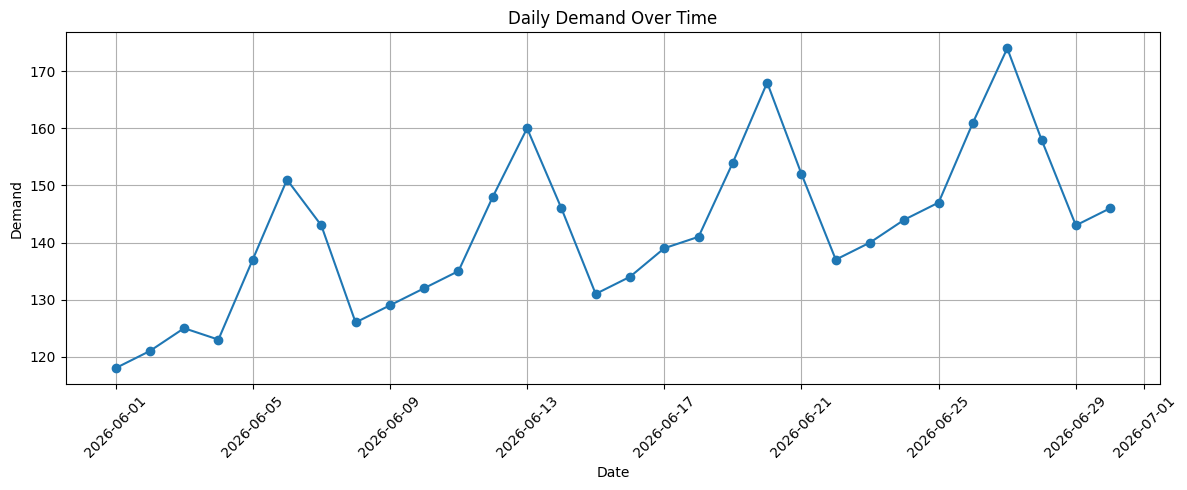

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["demand"],
    marker="o"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

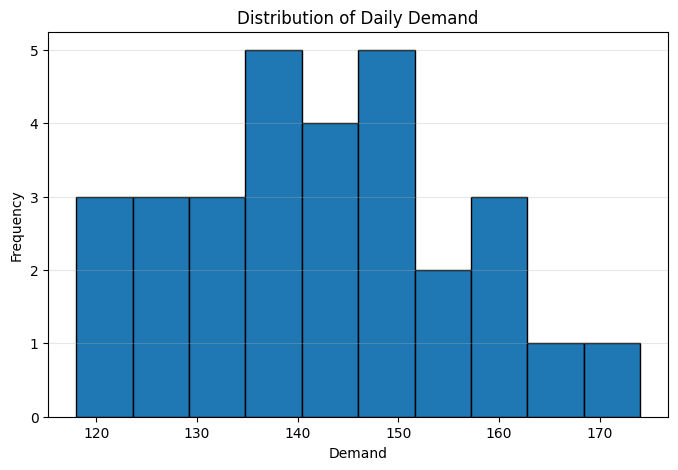

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["demand"], bins=10, edgecolor="black")

plt.title("Distribution of Daily Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 800x500 with 0 Axes>

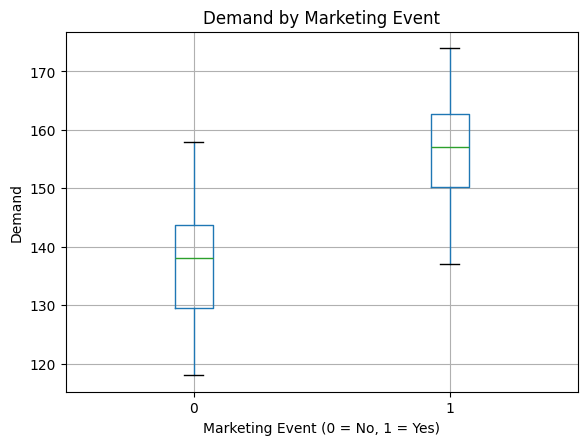

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="demand",
    by="marketing_event"
)

plt.title("Demand by Marketing Event")
plt.suptitle("")
plt.xlabel("Marketing Event (0 = No, 1 = Yes)")
plt.ylabel("Demand")

plt.show()

<Figure size 800x500 with 0 Axes>

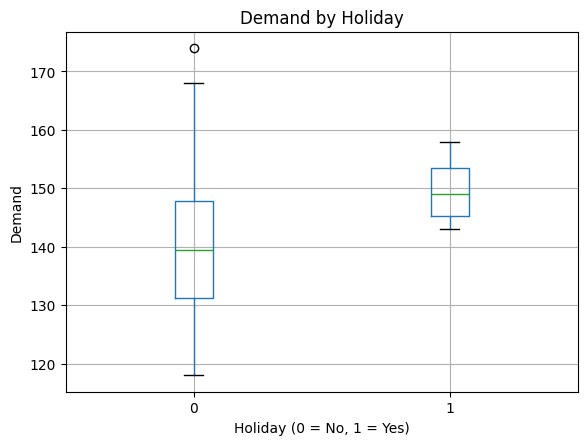

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="demand",
    by="holiday"
)

plt.title("Demand by Holiday")
plt.suptitle("")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Demand")

plt.show()

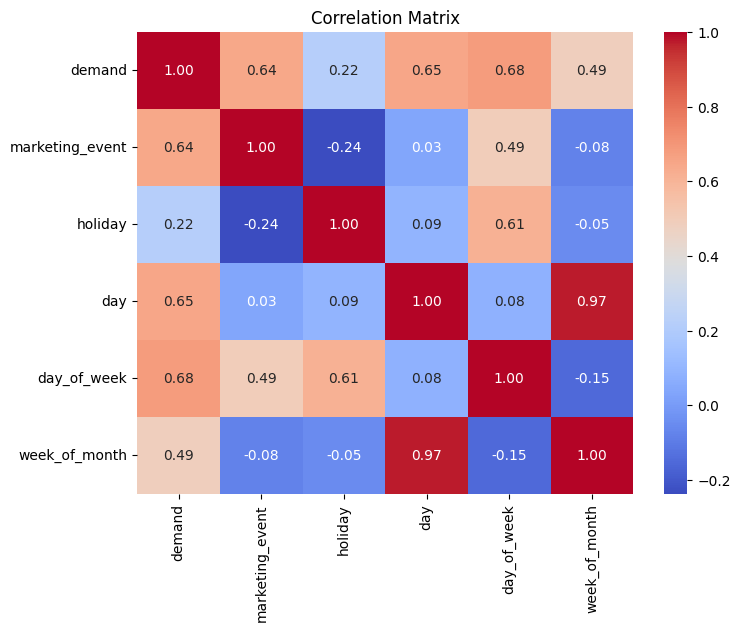

In [13]:
# Correlation matrix for numerical variables

correlation = df[
    ["demand", "marketing_event", "holiday", "day", "day_of_week", "week_of_month"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [14]:
marketing_summary = df.groupby("marketing_event")["demand"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(marketing_summary)

,count,mean,median,std,min,max
marketing_event,,,,,,
0,22,136.818182,138.0,10.450046,118,158
1,8,156.625000,157.0,11.710038,137,174


# 3. Predictive Modeling

The objective of this stage is to develop machine learning models capable of
predicting daily demand from calendar characteristics, marketing events, and
holiday indicators.

The data is divided chronologically into training and testing sets. This
approach prevents information from future dates from being used to train the
models.

In [15]:
# Define features and target

features = [
    "marketing_event",
    "holiday",
    "day",
    "day_of_week",
    "week_of_month"
]

X = df[features]
y = df["demand"]

# Chronological 80/20 split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [16]:
# Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {mae_linear:.2f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")

Linear Regression Results
-------------------------
MAE  : 2.82
RMSE : 3.15
R²   : 0.9143


In [17]:
# Random Forest Regression model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
---------------------
MAE  : 5.45
RMSE : 6.22
R²   : 0.6658


In [18]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,2.815506,3.149515,0.914344
1,Random Forest,5.450833,6.220987,0.665813


In [19]:
# Compare actual and predicted demand

comparison = pd.DataFrame({
    "Date": df["date"].iloc[split_index:].values,
    "Actual Demand": y_test.values,
    "Linear Regression": y_pred_linear,
    "Random Forest": y_pred_rf
})

display(comparison)

,Date,Actual Demand,Linear Regression,Random Forest
0,2026-06-25,147,148.729139,142.585
1,2026-06-26,161,164.840449,155.885
2,2026-06-27,174,168.635506,162.130
3,2026-06-28,158,160.737978,153.690
4,2026-06-29,143,144.212959,140.645
5,2026-06-30,146,148.008015,141.360


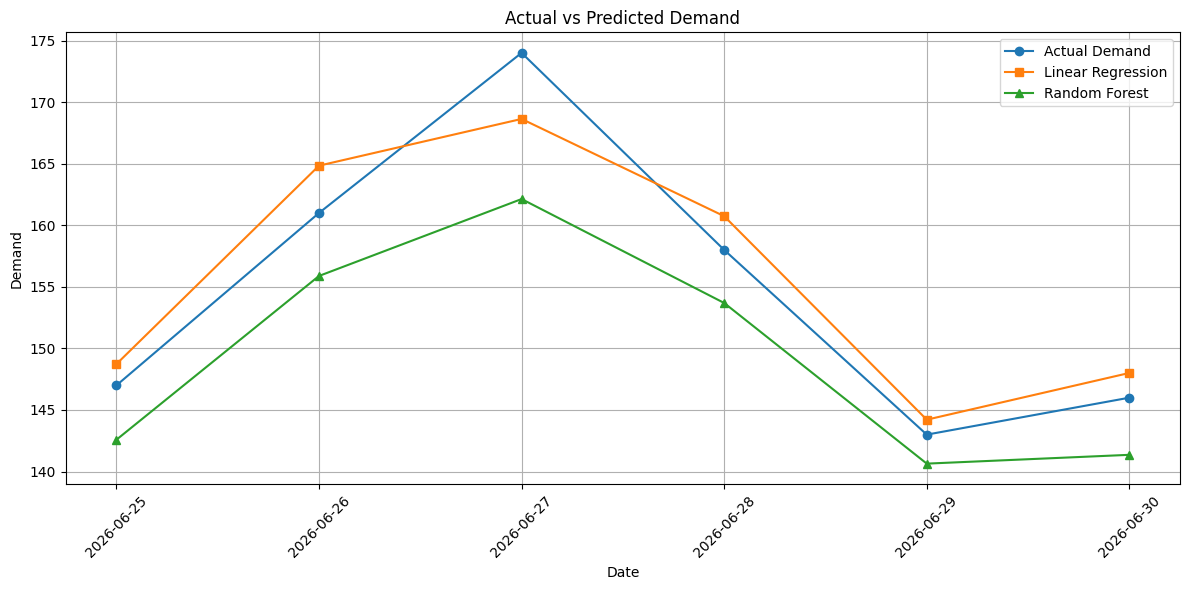

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Date"],
    comparison["Actual Demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    comparison["Date"],
    comparison["Linear Regression"],
    marker="s",
    label="Linear Regression"
)

plt.plot(
    comparison["Date"],
    comparison["Random Forest"],
    marker="^",
    label="Random Forest"
)

plt.title("Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Model Performance and Interpretation

Two regression models were evaluated: Linear Regression and Random Forest
Regression.

The Linear Regression model achieved an MAE of 2.82, RMSE of 3.15, and R² of
0.9143 on the test set. The Random Forest model achieved an MAE of 5.45,
RMSE of 6.22, and R² of 0.6658.

Lower MAE and RMSE indicate smaller prediction errors, while a higher R²
indicates that a larger proportion of the observed variation in the test
data is explained by the model.

For this dataset and chronological test split, Linear Regression produced
lower errors and a higher R² than Random Forest. Because the dataset contains
only 30 observations and the test set contains only 6 observations, these
results should be interpreted cautiously and should not be generalized
without validation on a larger dataset.

,Feature,Importance
3,day_of_week,0.550922
2,day,0.350683
0,marketing_event,0.047266
4,week_of_month,0.041487
1,holiday,0.009641


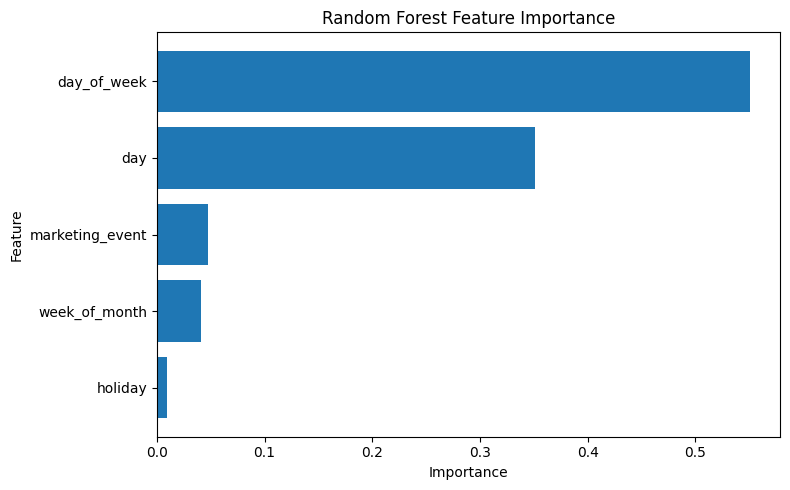

In [21]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Compare average demand during marketing events and non-event days

marketing_effect = df.groupby("marketing_event")["demand"].agg(
    ["count", "mean", "median", "std"]
)

print("Demand by Marketing Event")
display(marketing_effect)

# Compare average demand during holidays and non-holidays

holiday_effect = df.groupby("holiday")["demand"].agg(
    ["count", "mean", "median", "std"]
)

print("Demand by Holiday")
display(holiday_effect)

Demand by Marketing Event


,count,mean,median,std
marketing_event,,,,
0,22,136.818182,138.0,10.450046
1,8,156.625000,157.0,11.710038


Demand by Holiday


,count,mean,median,std
holiday,,,,
0,26,140.923077,139.5,14.355272
1,4,149.750000,149.0,6.652067


In [23]:
from scipy.stats import ttest_ind

event_demand = df[df["marketing_event"] == 1]["demand"]
non_event_demand = df[df["marketing_event"] == 0]["demand"]

t_stat, p_value = ttest_ind(
    event_demand,
    non_event_demand,
    equal_var=False
)

print("Independent Two-Sample t-Test")
print("--------------------------------")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05).")
else:
    print("Result: No statistically significant difference (p >= 0.05).")

Independent Two-Sample t-Test
--------------------------------
t-statistic: 4.2128
p-value: 0.0014
Result: Statistically significant difference (p < 0.05).


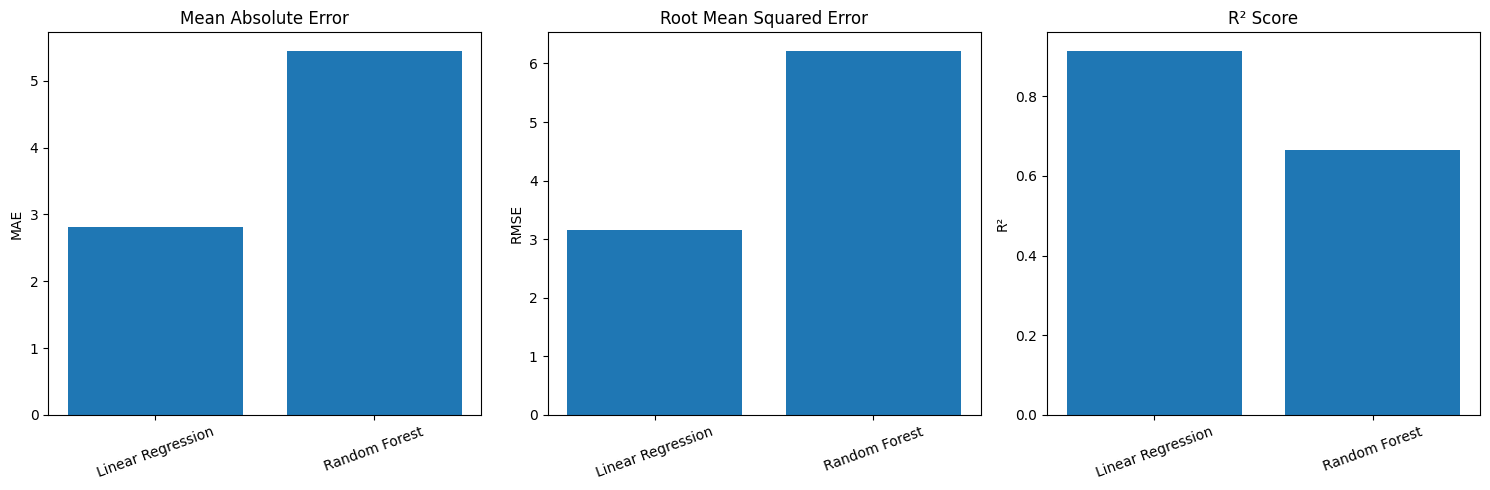

In [24]:
model_metrics = results.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(model_metrics["Model"], model_metrics["MAE"])
axes[0].set_title("Mean Absolute Error")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(model_metrics["Model"], model_metrics["RMSE"])
axes[1].set_title("Root Mean Squared Error")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(model_metrics["Model"], model_metrics["R2"])
axes[2].set_title("R² Score")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# 5. Research Findings

The analysis investigated whether historical demand, calendar characteristics,
marketing events, and holidays could be used to predict daily demand.

The dataset contained 30 daily observations. No missing values or duplicate
records were identified during data-quality analysis.

Two predictive models were evaluated using a chronological 80/20 train-test
split. Linear Regression achieved an MAE of 2.82, RMSE of 3.15, and R² of
0.9143 on the test set. Random Forest achieved an MAE of 5.45, RMSE of 6.22,
and R² of 0.6658.

The test-set results therefore show lower prediction error for Linear
Regression in this experiment. The model results should be interpreted
carefully because the dataset is small and the test set contains only six
observations.

The statistical analysis additionally examines whether demand differs between
marketing-event and non-event days. The resulting t-test is interpreted using
a significance level of 0.05.

# 6. Methodology

## 6.1 Research Design

This study follows a quantitative predictive analytics approach. The workflow
includes data inspection, preprocessing, exploratory data analysis, feature
engineering, statistical analysis, predictive modeling, and model evaluation.

## 6.2 Data Preparation

The dataset contains 30 daily observations with four original variables:
date, demand, marketing_event, and holiday.

The date variable was converted into a datetime format and additional
calendar features were created, including day of month, day of week, and
week of month.

The dataset was checked for missing values and duplicate records. No missing
values or duplicate rows were identified.

## 6.3 Exploratory Data Analysis

Exploratory analysis was performed using time-series plots, demand
distribution analysis, boxplots, summary statistics, and correlation analysis.

These techniques were used to investigate demand patterns and relationships
between demand and explanatory variables.

## 6.4 Statistical Analysis

An independent two-sample t-test was used to examine whether average demand
differed between marketing-event and non-marketing-event observations.

A significance level of 0.05 was used for hypothesis testing.

## 6.5 Predictive Modeling

Two supervised regression algorithms were evaluated:

1. Linear Regression
2. Random Forest Regression

The first 80% of observations in chronological order were used for training,
while the final 20% were reserved for testing.

A chronological split was selected because the observations represent dates,
and using future observations to train a model could introduce data leakage.

## 6.6 Evaluation Metrics

Model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

MAE and RMSE measure prediction error, while R² measures the proportion of
variance explained by the model.

# 7. Business Implications

Accurate demand prediction can support several operational and business
decisions.

### Inventory Planning

Demand forecasts can help organizations plan inventory levels and reduce the
risk of excessive inventory or stock shortages.

### Marketing Planning

The analysis of marketing-event indicators can help businesses investigate
whether promotional activities are associated with changes in demand.

### Workforce Planning

Demand estimates can support staffing and operational planning during periods
of higher expected demand.

### Demand Monitoring

A predictive model can be incorporated into a regular monitoring workflow so
that actual demand can be compared with predicted demand and unusual changes
can be investigated.

The results of this study should be treated as an initial analytical
prototype because the dataset is small. A larger historical dataset would be
required before using the model for high-stakes operational decisions.

# 8. Limitations

Several limitations should be considered when interpreting this study.

1. The dataset contains only 30 observations, which limits the statistical
   power and generalizability of the findings.

2. The chronological test set contains only six observations, meaning that
   model evaluation is based on a small sample.

3. The available predictor variables are limited to calendar characteristics,
   marketing events, and holidays.

4. Other potentially important demand drivers, such as price, weather,
   product availability, customer behavior, promotions, and economic
   conditions, are not included.

5. Only two predictive algorithms were evaluated.

6. The results represent the specific dataset and time period analyzed and
   should not automatically be generalized to other businesses or periods.

Future research should use a larger dataset covering multiple months or
years and should include additional demand-related variables.

# 9. Future Research

Future studies could improve the predictive framework by:

- Collecting several months or years of historical demand data.
- Adding price and discount information.
- Including weather and seasonal variables.
- Incorporating product and inventory information.
- Testing additional machine learning algorithms.
- Using time-series models such as ARIMA, SARIMA, or advanced forecasting
  approaches.
- Applying rolling or walk-forward validation.
- Performing hyperparameter optimization.
- Comparing predictions across different business segments or locations.

# 10. Conclusion

This research demonstrated a complete data science workflow for daily demand
prediction. The process included data-quality assessment, feature
engineering, exploratory analysis, statistical testing, predictive modeling,
and model evaluation.

Two regression approaches were evaluated using a chronological train-test
split. In the observed test set, Linear Regression produced an MAE of 2.82,
an RMSE of 3.15, and an R² of 0.9143, while Random Forest produced an MAE of
5.45, an RMSE of 6.22, and an R² of 0.6658.

These results demonstrate the feasibility of using the available variables
for demand prediction in this small experimental dataset. However, the small
sample size and limited test set mean that the results should be considered
preliminary rather than definitive.

The study provides a foundation for a larger demand forecasting system using
more historical observations and additional business-related variables.

# 11. References

1. Scikit-learn documentation — Machine Learning in Python.
2. Pandas documentation — Data Analysis and Manipulation.
3. NumPy documentation — Numerical Computing with Python.
4. Matplotlib documentation — Data Visualization.
5. Seaborn documentation — Statistical Data Visualization.
6. SciPy documentation — Scientific Computing and Statistical Analysis.